# Лабораторна робота. Комп'ютерний практикум 3

# Задача 2, варіант 2. Система:
$$\begin{cases} \dot{x} = -2y(x - y), \\ \dot{y} = 2 + x - y^2 \end{cases}$$

In [22]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp

sp.init_printing(use_unicode=True)

## 1. Положення рівноваги та системи першого наближення

In [23]:
x, y = sp.symbols('x y')

# Права частина системи
f = -2*y*(x - y)   # dx/dt
g = 2 + x - y**2   # dy/dt

print('Система:')
print(f'  ẋ = {f}')
print(f'  ẏ = {g}')
print()

# Знаходимо положення рівноваги
equilibria = sp.solve([f, g], [x, y])
print('Положення рівноваги (x*, y*):')
for i, eq in enumerate(equilibria):
    print(f'  P{i+1} = {eq}')

Система:
  ẋ = -2*y*(x - y)
  ẏ = x - y**2 + 2

Положення рівноваги (x*, y*):
  P1 = (-2, 0)
  P2 = (-1, -1)
  P3 = (2, 2)


In [24]:
# Матриця Якобі
J = sp.Matrix([[sp.diff(f, x), sp.diff(f, y)],
               [sp.diff(g, x), sp.diff(g, y)]])

print('Матриця Якобі J(x, y) =')
sp.pprint(J)
print()

labels = ['P1 = (-2, 0)', 'P2 = (-1, -1)', 'P3 = (2, 2)']
results = []

for i, (xstar, ystar) in enumerate(equilibria):
    J_val = J.subs([(x, xstar), (y, ystar)])
    tr = J_val.trace()
    det = J_val.det()
    disc = tr**2 - 4*det
    eigvals = J_val.eigenvals()
    
    results.append({
        'label': labels[i],
        'point': (xstar, ystar),
        'J': J_val,
        'tr': tr, 'det': det, 'disc': disc,
        'eigvals': eigvals
    })
    
    print(f'=== {labels[i]} ===')
    print('Система першого наближення: ξ̇ = Jξ, де J =')
    sp.pprint(J_val)
    print(f'  trace = {tr},  det = {det},  discriminant = {disc}')
    print(f'  Власні значення: {list(eigvals.keys())}')
    print()

Матриця Якобі J(x, y) =
⎡-2⋅y  -2⋅x + 4⋅y⎤
⎢                ⎥
⎣ 1       -2⋅y   ⎦

=== P1 = (-2, 0) ===
Система першого наближення: ξ̇ = Jξ, де J =
⎡0  4⎤
⎢    ⎥
⎣1  0⎦
  trace = 0,  det = -4,  discriminant = 16
  Власні значення: [-2, 2]

=== P2 = (-1, -1) ===
Система першого наближення: ξ̇ = Jξ, де J =
⎡2  -2⎤
⎢     ⎥
⎣1  2 ⎦
  trace = 4,  det = 6,  discriminant = -8
  Власні значення: [2 - sqrt(2)*I, 2 + sqrt(2)*I]

=== P3 = (2, 2) ===
Система першого наближення: ξ̇ = Jξ, де J =
⎡-4  4 ⎤
⎢      ⎥
⎣1   -4⎦
  trace = -8,  det = 12,  discriminant = 16
  Власні значення: [-2, -6]



## 2. Визначення типу кожного положення рівноваги

In [25]:
def classify_equilibrium(tr, det, disc):
    """
    Класифікація за критеріями:
    - det < 0  => Сідло
    - det > 0, disc > 0:
        tr < 0 => Стійкий вузол
        tr > 0 => Нестійкий вузол
    - det > 0, disc < 0:
        tr < 0 => Стійкий фокус
        tr > 0 => Нестійкий фокус
        tr = 0 => Центр
    - disc = 0:
        tr < 0 => Стійкий виродж. вузол
        tr > 0 => Нестійкий виродж. вузол
    """
    tr_n = float(tr)
    det_n = float(det)
    disc_n = float(disc)
    
    if det_n < 0:
        return 'Сідло (нестійке)'
    elif det_n > 0:
        if disc_n > 0:
            if tr_n < 0:
                return 'Стійкий вузол'
            elif tr_n > 0:
                return 'Нестійкий вузол'
        elif disc_n < 0:
            if tr_n < 0:
                return 'Стійкий фокус'
            elif tr_n > 0:
                return 'Нестійкий фокус'
            else:
                return 'Центр'
        else:  # disc = 0
            return 'Виродж. вузол'
    else:
        return 'Центр (det=0, особливий випадок)'

print('Класифікація положень рівноваги:')
print('='*55)
for r in results:
    etype = classify_equilibrium(r['tr'], r['det'], r['disc'])
    r['type'] = etype
    print(f"{r['label']:15s}  =>  {etype}")
    print(f"   tr={r['tr']}, det={r['det']}, disc={r['disc']}")
    print()

Класифікація положень рівноваги:
P1 = (-2, 0)     =>  Сідло (нестійке)
   tr=0, det=-4, disc=16

P2 = (-1, -1)    =>  Нестійкий фокус
   tr=4, det=6, disc=-8

P3 = (2, 2)      =>  Стійкий вузол
   tr=-8, det=12, disc=16



## 3. Фазовий портрет: напрямки векторного поля на сітці

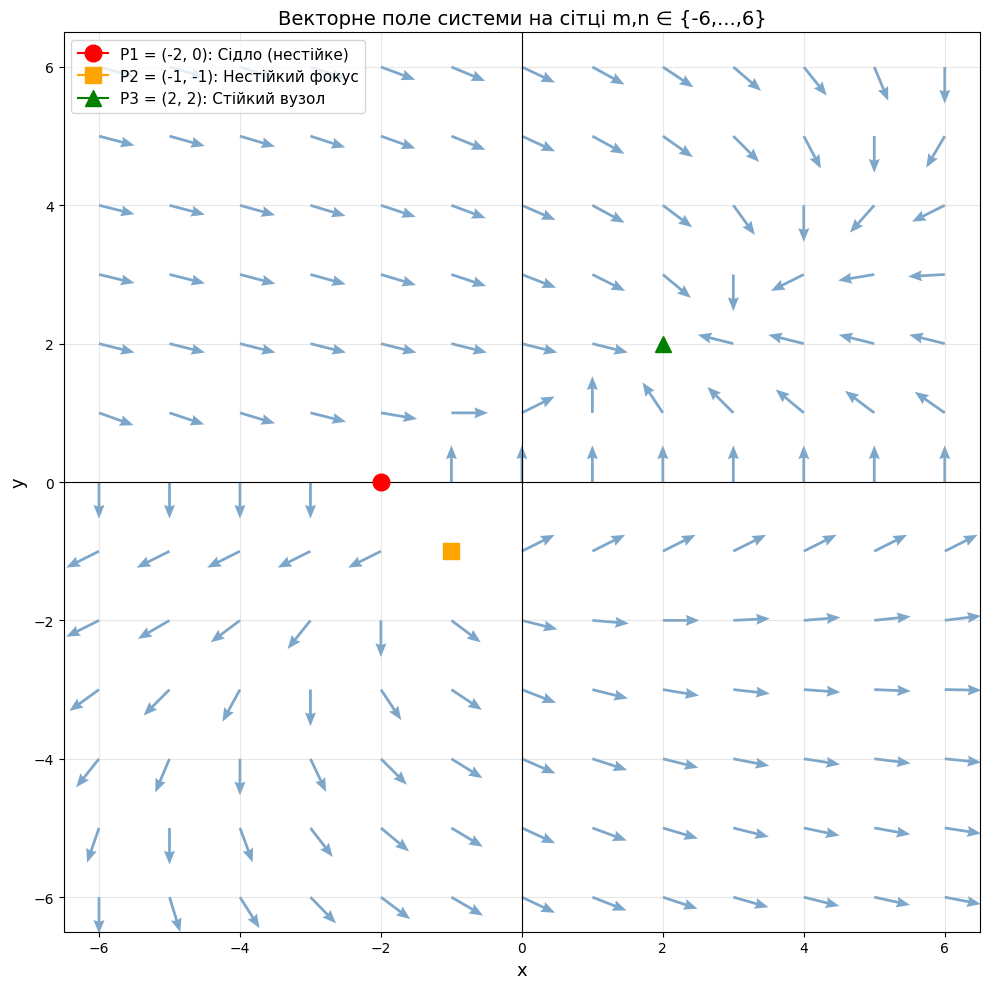

In [26]:
def F(X, Y):
    return -2*Y*(X - Y)

def G(X, Y):
    return 2 + X - Y**2

# Сітка m, n = -6..6
m = np.arange(-6, 7)
n = np.arange(-6, 7)
M, N = np.meshgrid(m, n)

U = F(M, N)
V = G(M, N)

# Нормування для стрілок
norm = np.sqrt(U**2 + V**2)
norm[norm == 0] = 1
U_norm = U / norm
V_norm = V / norm

fig, ax = plt.subplots(figsize=(10, 10))

ax.quiver(M, N, U_norm, V_norm,
          color='steelblue', alpha=0.7,
          scale=25, width=0.003,
          headwidth=4, headlength=5)

colors = ['red', 'orange', 'green']
markers = ['o', 's', '^']
for r, c, mk in zip(results, colors, markers):
    px, py = float(r['point'][0]), float(r['point'][1])
    ax.plot(px, py, marker=mk, color=c, markersize=12,
            label=f"{r['label']}: {r['type']}", zorder=5)

ax.set_xlim(-6.5, 6.5)
ax.set_ylim(-6.5, 6.5)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Векторне поле системи на сітці m,n ∈ {-6,...,6}', fontsize=14)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Poshtak_task_3_2_vector_field.png', dpi=150)
plt.show()

## 4. Фазові траєкторії в околах положень рівноваги

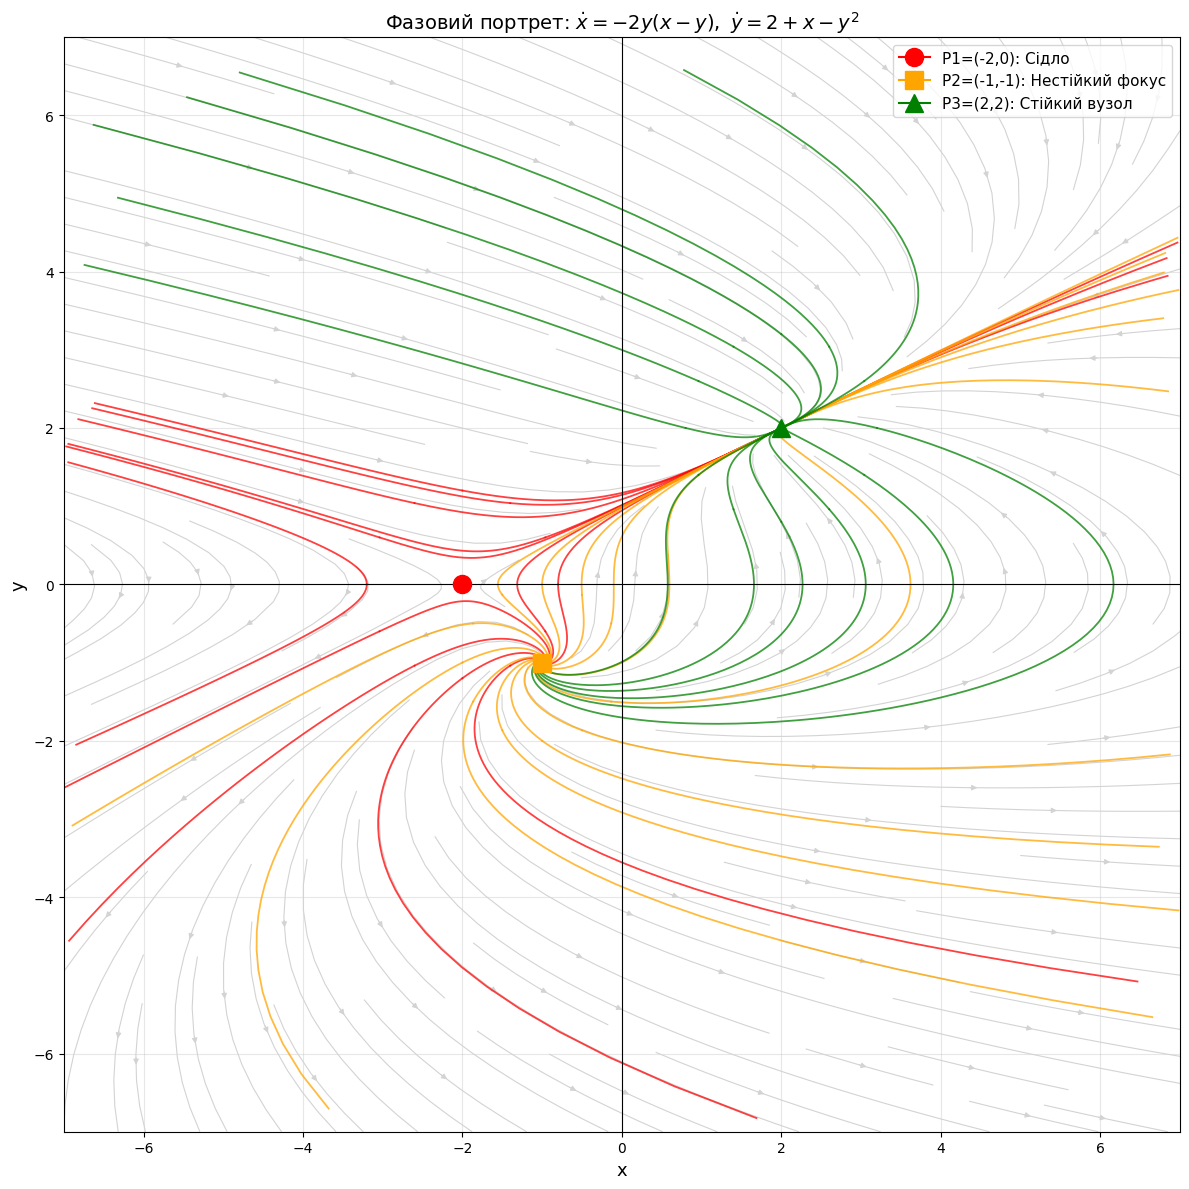

In [27]:
def system(t, state):
    xi, yi = state
    return [F(xi, yi), G(xi, yi)]

def get_ic_around(cx, cy, r=1.5, n=16):
    """Початкові умови рівномірно навколо точки (cx, cy)"""
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    return [(cx + r*np.cos(a), cy + r*np.sin(a)) for a in angles]

# ---- Один великий фазовий портрет ----
fig, ax = plt.subplots(figsize=(12, 12))

# Фонове векторне поле
xg = np.linspace(-7, 7, 30)
yg = np.linspace(-7, 7, 30)
Xg, Yg = np.meshgrid(xg, yg)
Ug = F(Xg, Yg)
Vg = G(Xg, Yg)
normg = np.sqrt(Ug**2 + Vg**2)
normg[normg == 0] = 1
ax.streamplot(Xg, Yg, Ug, Vg,
              density=1.4, color='lightgray',
              linewidth=0.8, arrowsize=0.8)

# Точки рівноваги та локальні траєкторії
eq_data = [
    {'point': (-2, 0),  'r': 1.2, 'color': 'red',    'label': 'P1=(-2,0): Сідло'},
    {'point': (-1, -1), 'r': 1.0, 'color': 'orange',  'label': 'P2=(-1,-1): Нестійкий фокус'},
    {'point': (2, 2),   'r': 1.2, 'color': 'green',   'label': 'P3=(2,2): Стійкий вузол'},
]

t_span_fwd = (0, 8)
t_span_bwd = (0, -8)
t_eval_fwd = np.linspace(0,  8, 800)
t_eval_bwd = np.linspace(0, -8, 800)

for eqd in eq_data:
    cx, cy = eqd['point']
    col = eqd['color']
    ics = get_ic_around(cx, cy, r=eqd['r'], n=12)
    
    for ic in ics:
        for tspan, teval in [(t_span_fwd, t_eval_fwd), (t_span_bwd, t_eval_bwd)]:
            try:
                sol = solve_ivp(system, tspan, ic, t_eval=teval,
                                max_step=0.05, dense_output=False,
                                method='RK45', rtol=1e-8, atol=1e-10)
                xs, ys = sol.y[0], sol.y[1]
                # Обмежуємо відображення
                mask = (np.abs(xs) < 7) & (np.abs(ys) < 7)
                # Розбиваємо на неперервні шматки
                idx = np.where(np.diff(mask.astype(int)) != 0)[0]
                segs = np.split(np.arange(len(xs)), idx+1)
                for seg in segs:
                    if len(seg) > 2 and mask[seg[0]]:
                        ax.plot(xs[seg], ys[seg], color=col,
                                alpha=0.75, lw=1.3)
            except Exception:
                pass

# Позначення точок рівноваги
markers = ['o', 's', '^']
for eqd, mk in zip(eq_data, markers):
    cx, cy = eqd['point']
    ax.plot(cx, cy, marker=mk, color=eqd['color'],
            markersize=13, zorder=10,
            label=eqd['label'])

ax.set_xlim(-7, 7)
ax.set_ylim(-7, 7)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Фазовий портрет: $\\dot{x}=-2y(x-y),\ \\dot{y}=2+x-y^2$', fontsize=14)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Poshtak_task_3_2_phase_portrait.png', dpi=150)
plt.show()

## 5. Збільшені портрети поблизу кожної точки рівноваги

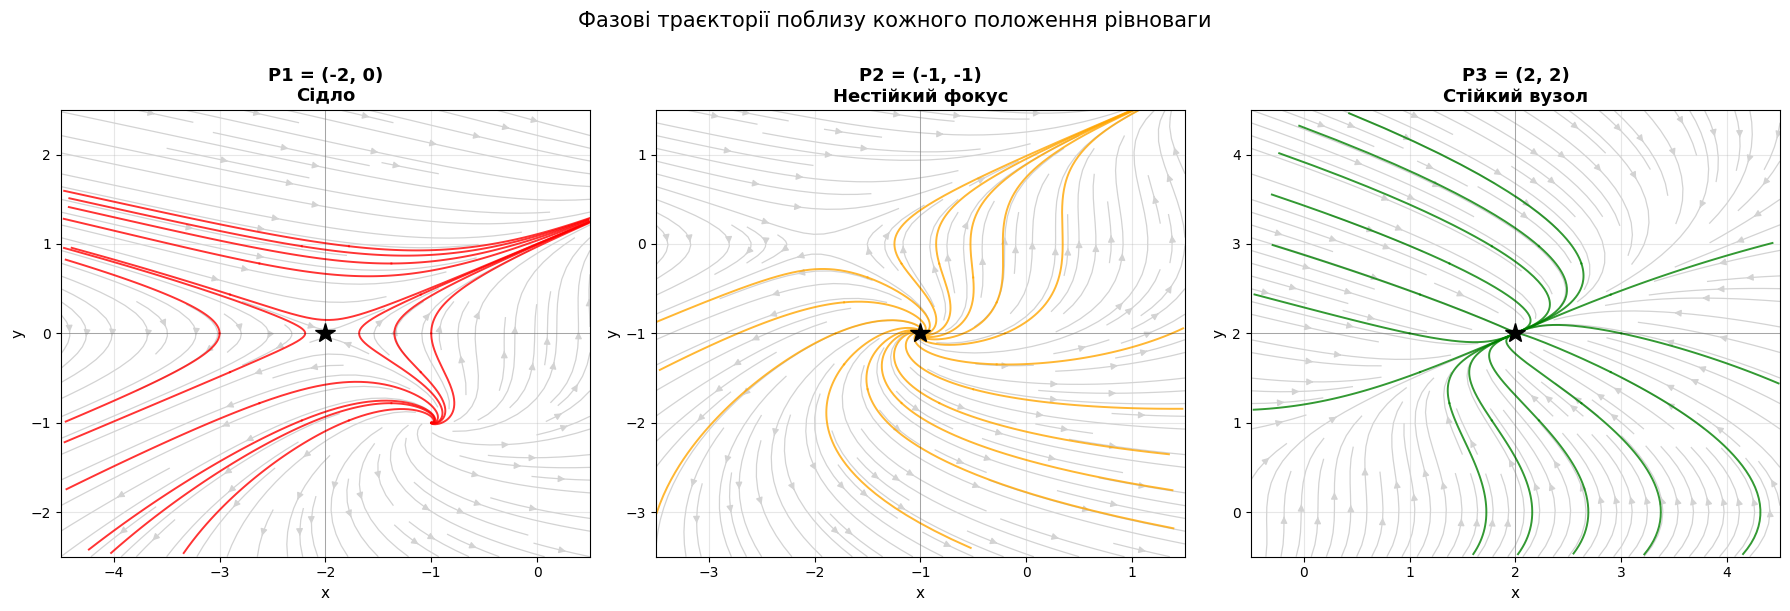

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

local_config = [
    {'point': (-2, 0),  'half': 2.5, 'r': 1.0, 'n': 14,
     'color': 'red',   'title': 'P1 = (-2, 0)\nСідло'},
    {'point': (-1, -1), 'half': 2.5, 'r': 0.8, 'n': 14,
     'color': 'orange','title': 'P2 = (-1, -1)\nНестійкий фокус'},
    {'point': (2, 2),   'half': 2.5, 'r': 1.0, 'n': 14,
     'color': 'green', 'title': 'P3 = (2, 2)\nСтійкий вузол'},
]

for ax, cfg in zip(axes, local_config):
    cx, cy = cfg['point']
    h = cfg['half']
    col = cfg['color']
    
    # Локальне векторне поле
    xl = np.linspace(cx-h, cx+h, 20)
    yl = np.linspace(cy-h, cy+h, 20)
    Xl, Yl = np.meshgrid(xl, yl)
    Ul = F(Xl, Yl); Vl = G(Xl, Yl)
    ax.streamplot(Xl, Yl, Ul, Vl,
                  density=1.2, color='lightgray',
                  linewidth=0.9, arrowsize=1.0)
    
    ics = get_ic_around(cx, cy, r=cfg['r'], n=cfg['n'])
    for ic in ics:
        for tspan, teval in [(t_span_fwd, t_eval_fwd), (t_span_bwd, t_eval_bwd)]:
            try:
                sol = solve_ivp(system, tspan, ic, t_eval=teval,
                                max_step=0.02, rtol=1e-9, atol=1e-11)
                xs, ys = sol.y[0], sol.y[1]
                mask = ((xs > cx-h) & (xs < cx+h) &
                        (ys > cy-h) & (ys < cy+h))
                idx = np.where(np.diff(mask.astype(int)) != 0)[0]
                segs = np.split(np.arange(len(xs)), idx+1)
                for seg in segs:
                    if len(seg) > 2 and mask[seg[0]]:
                        ax.plot(xs[seg], ys[seg], color=col,
                                alpha=0.8, lw=1.4)
            except Exception:
                pass
    
    ax.plot(cx, cy, 'k*', markersize=15, zorder=10)
    ax.set_xlim(cx-h, cx+h)
    ax.set_ylim(cy-h, cy+h)
    ax.set_title(cfg['title'], fontsize=13, fontweight='bold')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.axhline(cy, color='black', lw=0.5, alpha=0.4)
    ax.axvline(cx, color='black', lw=0.5, alpha=0.4)
    ax.grid(True, alpha=0.3)

plt.suptitle('Фазові траєкторії поблизу кожного положення рівноваги',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('Poshtak_task_3_2_local_portraits.png', dpi=150)
plt.show()

## Підсумок

| Точка | Власні значення | Слід | Визн. | Тип |
|-------|----------------|------|-------|-----|
| P1 = (-2, 0) | λ₁=-2, λ₂=2 | 0 | -4 | **Сідло** (нестійке) |
| P2 = (-1,-1) | λ = 2 ± i√2 | 4 | 6 | **Нестійкий фокус** |
| P3 = (2, 2) | λ₁=-2, λ₂=-6 | -8 | 12 | **Стійкий вузол** |

**Критерії класифікації:**
- `det(J) < 0` → Сідло  
- `det(J) > 0, Δ = tr²-4det > 0, tr < 0` → Стійкий вузол  
- `det(J) > 0, Δ < 0, tr > 0` → Нестійкий фокус